In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
df = pd.read_csv("aqi.csv")
df.head()

,date,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit,note
0,30-04-2025,Maharashtra,Amravati,2,PM10,78,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
1,30-04-2025,Bihar,Purnia,1,CO,56,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
2,30-04-2025,Madhya Pradesh,Katni,1,O3,98,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
3,30-04-2025,Chhattisgarh,Tumidih,1,PM10,103,Moderate,number_of_monitoring_stations in Absolute Numb...,NaN
4,30-04-2025,Assam,Byrnihat,1,PM2.5,61,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN


In [43]:
df['state']=df['state'].str.upper()
df['area']=df['area'].str.upper()

In [44]:
df['state'].unique()

array(['MAHARASHTRA', 'BIHAR', 'MADHYA PRADESH', 'CHHATTISGARH', 'ASSAM',
       'MANIPUR', 'KERALA', 'WEST BENGAL', 'ODISHA', 'KARNATAKA',
       'GUJARAT', 'UTTARAKHAND', 'TAMIL NADU', 'ANDHRA PRADESH',
       'RAJASTHAN', 'UTTAR PRADESH', 'PUNJAB', 'MIZORAM', 'CHANDIGARH',
       'TELANGANA', 'PUDUCHERRY', 'MEGHALAYA', 'HIMACHAL PRADESH',
       'JHARKHAND', 'HARYANA', 'ARUNACHAL PRADESH', 'NAGALAND', 'TRIPURA',
       'DELHI', 'ANDAMAN AND NICOBAR ISLANDS', 'SIKKIM',
       'JAMMU AND KASHMIR'], dtype=object)

In [45]:
df['state'].nunique()

32

In [46]:
df['area'].unique()

array(['AMRAVATI', 'PURNIA', 'KATNI', 'TUMIDIH', 'BYRNIHAT', 'IMPHAL',
       'KOLLAM', 'BARRACKPORE', 'NAYAGARH', 'NALBARI', 'HUBBALLI',
       'AHMEDABAD', 'DEHRADUN', 'VELLORE', 'ULHASNAGAR', 'CHENGALPATTU',
       'TIRUPATI', 'DINDIGUL', 'KADAPA', 'THANE', 'RISHIKESH', 'RAIPUR',
       'RANIPET', 'SAMASTIPUR', 'JABALPUR', 'KISHANGANJ', 'SAHARSA',
       'YADGIR', 'DUNGARPUR', 'MEERUT', 'SAWAI MADHOPUR', 'GHAZIABAD',
       'PITHAMPUR', 'KANPUR', 'CHENNAI', 'NAGAUR', 'CHITTOOR', 'KALYAN',
       'MIRA BHAYANDAR', 'BHUBANESWAR', 'CHURU', 'JODHPUR', 'KATIHAR',
       'PALI', 'BALASORE', 'SIKAR', 'JALANDHAR', 'TIRUMALA', 'ANGUL',
       'PATIALA', 'PIMPRI CHINCHWAD', 'VATVA', 'CHAMARAJANAGAR',
       'JAISALMER', 'KEONJHAR', 'CHITTORGARH', 'CHIKKABALLAPUR',
       'BHILWARA', 'ARRAH', 'AGRA', 'KOTA', 'CHIKKAMAGALURU', 'BHARATPUR',
       'AIZAWL', 'GANDHI NAGAR', 'DAUSA', 'KUNJEMURA', 'MOTIHARI',
       'UJJAIN', 'SALEM', 'VIJAYAWADA', 'THOOTHUKUDI', 'DAVANAGERE',
       'COIMBATORE', 

In [47]:
df['area'].nunique()

291

In [48]:
# Group areas by state
state_vector = df.groupby('state')['area'].unique().to_dict()

In [49]:
for state in sorted(state_vector.keys()):
    print(f"\n{state} ({len(state_vector[state])} areas):")
    print(sorted(list(state_vector[state])))


ANDAMAN AND NICOBAR ISLANDS (1 areas):
['SRI VIJAYA PURAM']

ANDHRA PRADESH (9 areas):
['AMARAVATI', 'ANANTAPUR', 'CHITTOOR', 'KADAPA', 'RAJAMAHENDRAVARAM', 'TIRUMALA', 'TIRUPATI', 'VIJAYAWADA', 'VISAKHAPATNAM']

ARUNACHAL PRADESH (1 areas):
['NAHARLAGUN']

ASSAM (6 areas):
['BYRNIHAT', 'GUWAHATI', 'NAGAON', 'NALBARI', 'SILCHAR', 'SIVASAGAR']

BIHAR (25 areas):
['ARARIA', 'ARRAH', 'AURANGABAD', 'BEGUSARAI', 'BETTIAH', 'BHAGALPUR', 'BIHAR SHARIF', 'BUXAR', 'CHHAPRA', 'DARBHANGA', 'GAYA', 'HAJIPUR', 'KATIHAR', 'KISHANGANJ', 'MANGURAHA', 'MOTIHARI', 'MUNGER', 'MUZAFFARPUR', 'PATNA', 'PURNIA', 'RAJGIR', 'SAHARSA', 'SAMASTIPUR', 'SASARAM', 'SIWAN']

CHANDIGARH (1 areas):
['CHANDIGARH']

CHHATTISGARH (8 areas):
['BHILAI', 'BILASPUR', 'CHHAL', 'KORBA', 'KUNJEMURA', 'MILUPARA', 'RAIPUR', 'TUMIDIH']

DELHI (1 areas):
['DELHI']

GUJARAT (7 areas):
['AHMEDABAD', 'ANKLESHWAR', 'GANDHI NAGAR', 'NANDESARI', 'SURAT', 'VAPI', 'VATVA']

HARYANA (25 areas):
['AMBALA', 'BAHADURGARH', 'BALLABGARH', 'BHIW

In [50]:
len(state_vector) # 28 States + 8 UTS

32

In [51]:
# Separate States and Union Territories

ut_list = [
    'ANDAMAN AND NICOBAR ISLANDS','CHANDIGARH','DELHI',
    'PUDUCHERRY','JAMMU AND KASHMIR','LADAKH',
    'DADRA AND NAGAR HAVELI AND DAMAN AND DIU','LAKSHADWEEP'
]

df_states = df[~df['state'].isin(ut_list)]
df_uts = df[df['state'].isin(ut_list)]

In [88]:
df_uts.head()

,date,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit,note
79,30-04-2025,CHANDIGARH,CHANDIGARH,3,"PM10,O3",118,Moderate,number_of_monitoring_stations in Absolute Numb...,NaN
96,30-04-2025,PUDUCHERRY,PUDUCHERRY,1,O3,28,Good,number_of_monitoring_stations in Absolute Numb...,NaN
210,30-04-2025,DELHI,DELHI,36,O3,198,Moderate,number_of_monitoring_stations in Absolute Numb...,NaN
231,29-04-2025,PUDUCHERRY,PUDUCHERRY,1,PM10,22,Good,number_of_monitoring_stations in Absolute Numb...,NaN
351,29-04-2025,ANDAMAN AND NICOBAR ISLANDS,SRI VIJAYA PURAM,1,PM10,53,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN


In [52]:
state_aqi = df_states.groupby('state')['aqi_value'].mean().sort_values(ascending=False)
print(state_aqi)

state
JHARKHAND            164.940361
HIMACHAL PRADESH     160.257036
BIHAR                157.158122
HARYANA              140.852806
RAJASTHAN            127.987248
TRIPURA              126.697585
UTTAR PRADESH        126.424036
ODISHA               124.879719
PUNJAB               117.854265
WEST BENGAL          114.192891
ASSAM                114.117456
GUJARAT              110.634272
MADHYA PRADESH       108.716483
MAHARASHTRA          103.639833
MANIPUR              100.927361
UTTARAKHAND           87.898799
TELANGANA             81.012444
NAGALAND              80.458725
CHHATTISGARH          78.986321
ANDHRA PRADESH        77.507701
KERALA                68.070147
TAMIL NADU            67.757654
MEGHALAYA             62.731121
KARNATAKA             62.672853
ARUNACHAL PRADESH     54.485265
SIKKIM                53.688995
MIZORAM               47.247000
Name: aqi_value, dtype: float64


In [53]:
top_cities = df.groupby('area')['aqi_value'].mean().sort_values(ascending=False).head(10)
print(top_cities)

area
BYRNIHAT          239.995427
BEGUSARAI         206.680412
DELHI             206.416889
GREATER NOIDA     201.601959
SRI GANGANAGAR    197.939351
GURUGRAM          190.848214
DARBHANGA         190.089844
DHARUHERA         185.722513
NOIDA             183.989324
GHAZIABAD         183.010676
Name: aqi_value, dtype: float64


In [54]:
worst_city_per_state = df.loc[df.groupby('state')['aqi_value'].idxmax()]
print(worst_city_per_state[['state','area','aqi_value']])

                              state              area  aqi_value
3961    ANDAMAN AND NICOBAR ISLANDS  SRI VIJAYA PURAM        150
174386               ANDHRA PRADESH        VIJAYAWADA        500
95822             ARUNACHAL PRADESH        NAHARLAGUN        183
189653                        ASSAM          BYRNIHAT        442
192656                        BIHAR             SIWAN        488
39012                    CHANDIGARH        CHANDIGARH        412
116463                 CHHATTISGARH         KUNJEMURA        345
38137                         DELHI             DELHI        494
145906                      GUJARAT             SURAT        384
38068                       HARYANA          GURUGRAM        469
111833             HIMACHAL PRADESH             BADDI        438
165664            JAMMU AND KASHMIR          SRINAGAR        251
86468                     JHARKHAND           DHANBAD        436
196221                    KARNATAKA             GADAG        500
196542                   

In [55]:
df['air_quality_status'].value_counts()

air_quality_status
Satisfactory    88897
Moderate        77537
Good            41971
Poor            21154
Very Poor        5671
Severe            555
Name: count, dtype: int64

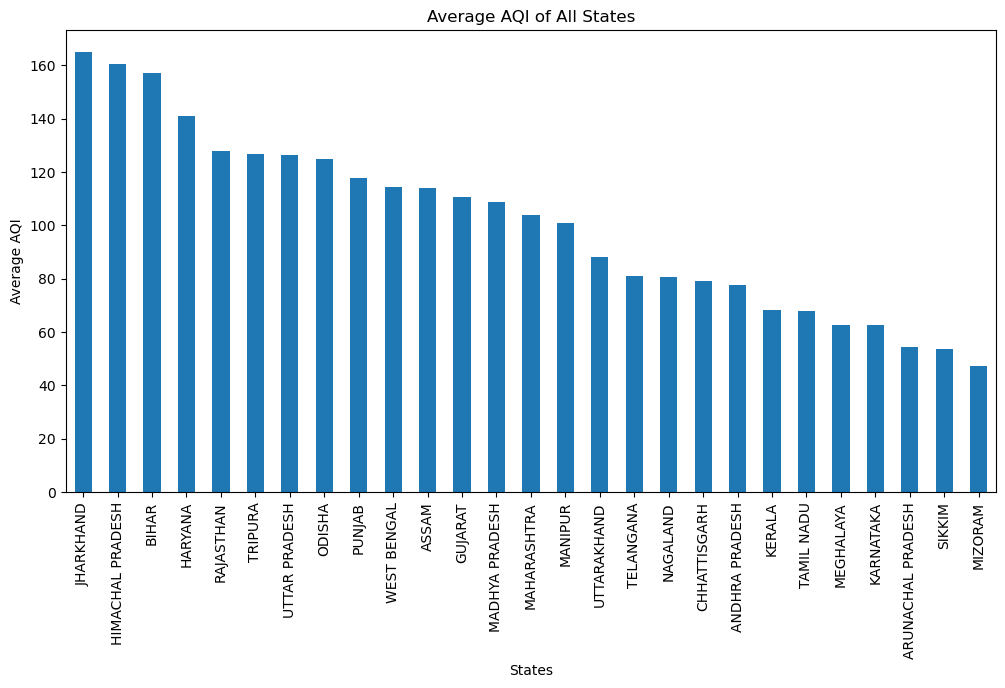

In [90]:
# Plot average AQI for all STATES (excluding Union Territories)

plt.figure(figsize=(12,6))

state_aqi_states = df_states.groupby('state')['aqi_value'].mean().sort_values(ascending=False)

state_aqi_states.plot(kind='bar')

plt.title("Average AQI of All States")
plt.xlabel("States")
plt.ylabel("Average AQI")
plt.xticks(rotation=90)

plt.show()

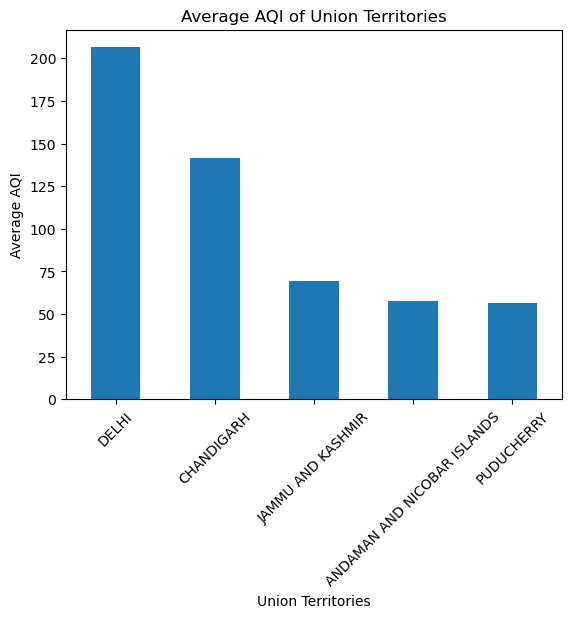

In [57]:
# Plot average AQI for all UNION TERRITORIES
# This shows pollution levels in UTs separately from states

plt.figure()

state_aqi_uts = df_uts.groupby('state')['aqi_value'].mean().sort_values(ascending=False)

state_aqi_uts.plot(kind='bar')

plt.title("Average AQI of Union Territories")
plt.xlabel("Union Territories")
plt.ylabel("Average AQI")
plt.xticks(rotation=45)

plt.show()

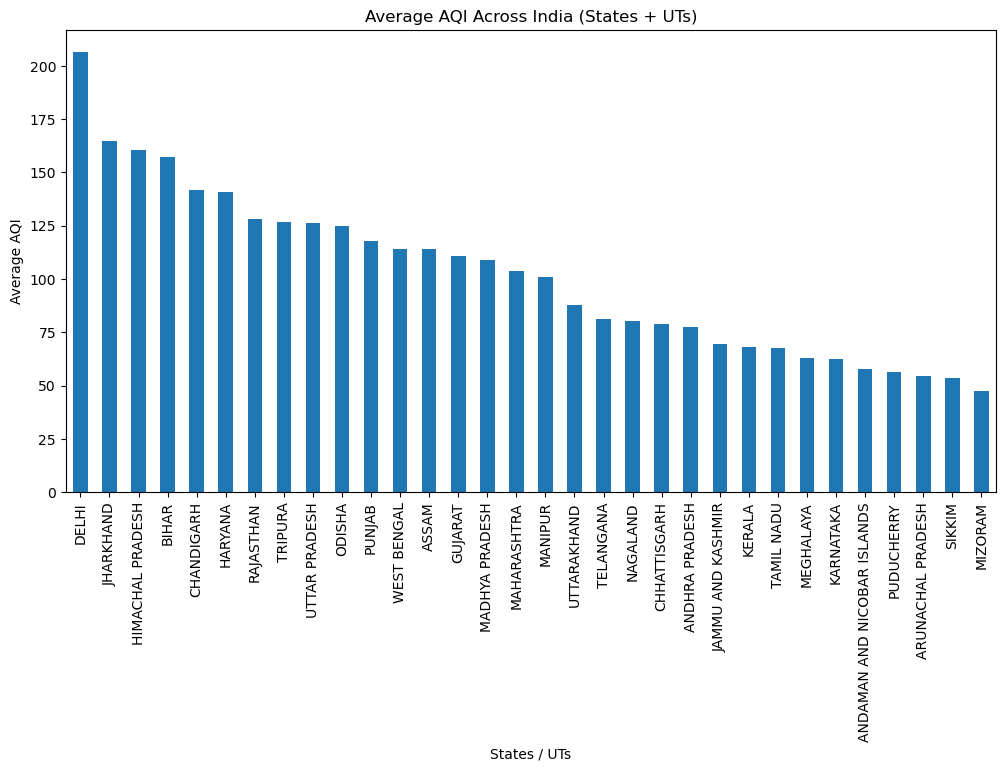

In [92]:
# Plot average AQI for ALL regions (States + UTs combined)
# This gives a complete national comparison of pollution levels

plt.figure(figsize=(12,6))

state_aqi_all = df.groupby('state')['aqi_value'].mean().sort_values(ascending=False)

state_aqi_all.plot(kind='bar')

plt.title("Average AQI Across India (States + UTs)")
plt.xlabel("States / UTs")
plt.ylabel("Average AQI")
plt.xticks(rotation=90)

plt.show()

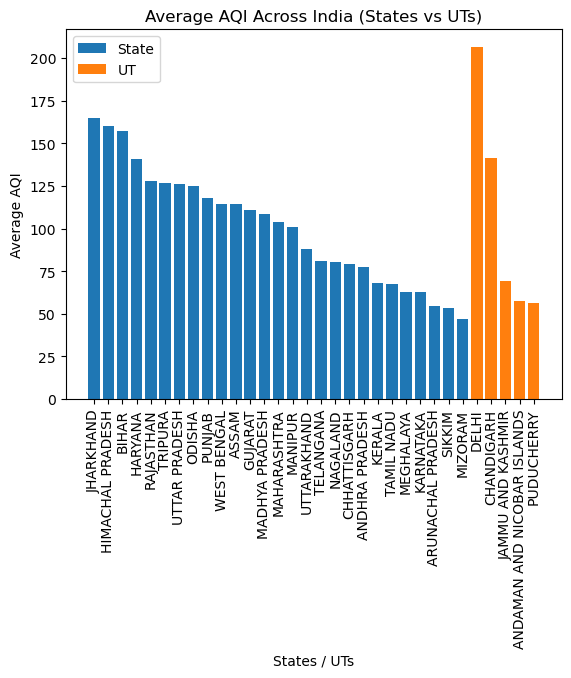

In [59]:
labels = ['UT' if state in ut_list else 'State' for state in state_aqi_all.index]

# Convert to DataFrame for easier plotting

plot_df = pd.DataFrame({
    'AQI': state_aqi_all,
    'Type': labels
})

# Plot
plt.figure()

for t, group in plot_df.groupby('Type'):
    plt.bar(group.index, group['AQI'], label=t)

plt.title("Average AQI Across India (States vs UTs)")
plt.xlabel("States / UTs")
plt.ylabel("Average AQI")
plt.xticks(rotation=90)

plt.legend()  # shows State vs UT

plt.show()

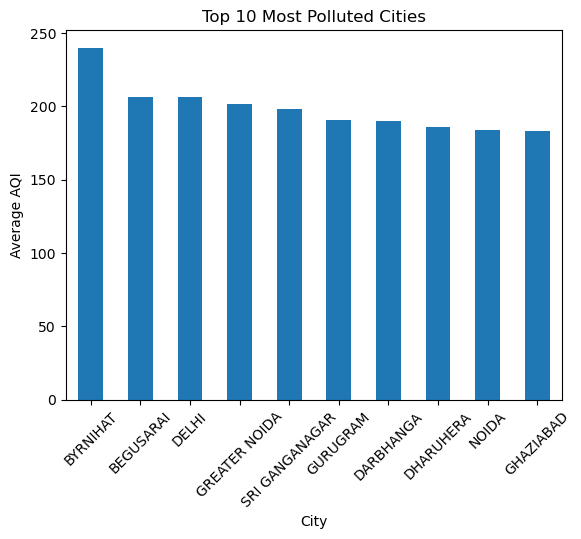

In [60]:
# Plot top 10 most polluted cities based on average AQI

plt.figure()

city_aqi = df.groupby('area')['aqi_value'].mean().sort_values(ascending=False)

top_cities = city_aqi.head(10)

top_cities.plot(kind='bar')

plt.title("Top 10 Most Polluted Cities")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.xticks(rotation=45)

plt.show()

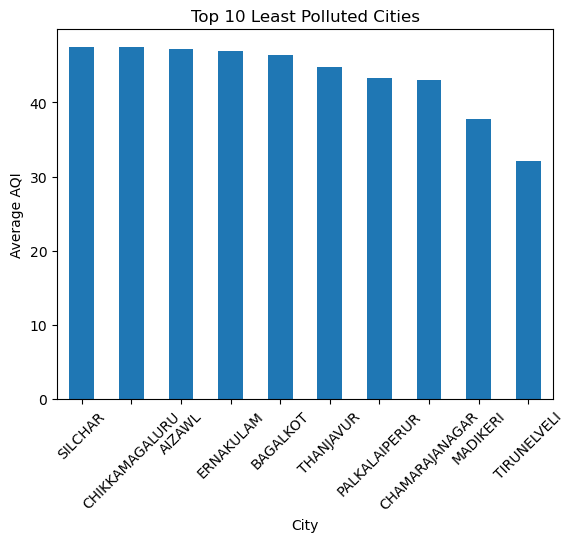

In [61]:
# Plot top 10 least polluted cities based on average AQI

plt.figure()

least_cities = city_aqi.tail(10)

least_cities.plot(kind='bar')

plt.title("Top 10 Least Polluted Cities")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.xticks(rotation=45)

plt.show()

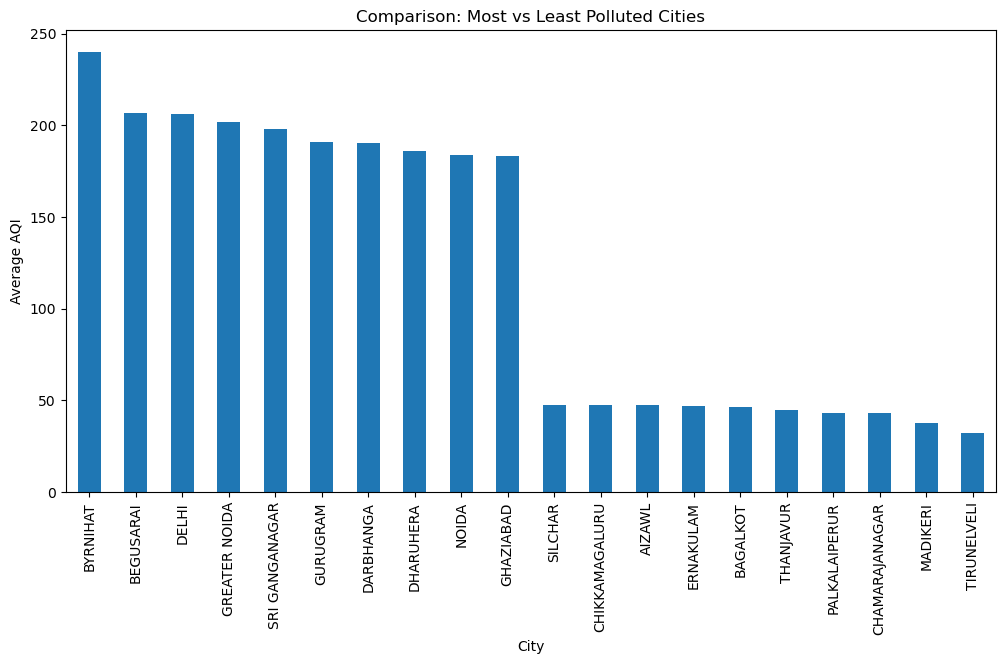

In [94]:
# Combine top and least polluted cities in one graph for comparison

combined = pd.concat([top_cities, least_cities])

plt.figure(figsize=(12,6))

combined.plot(kind='bar')

plt.title("Comparison: Most vs Least Polluted Cities")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.xticks(rotation=90)

plt.show()